# Analisis E-Commerce Public Dataset

## Tujuan
Proyek ini menganalisis performa penjualan dan hubungan ketepatan pengiriman dengan kepuasan pelanggan menggunakan E-Commerce Public Dataset.

### Business Questions

**BQ1.** Bagaimana perkembangan total revenue dan jumlah order secara bulanan selama periode September 2016 hingga Oktober 2018, dan kategori produk apa yang memberikan kontribusi revenue terbesar?

**BQ2.** Seberapa besar perbedaan rata-rata review score antara pesanan yang dikirim tepat waktu dan pesanan yang terlambat selama periode 2017 hingga 2018?

### Alur Analisis
1. Data Gathering
2. Assessing Data
3. Data Cleaning
4. Exploratory Data Analysis
5. Visualization & Explanatory Analysis
6. Conclusion & Recommendation

## 1. Import Library

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

## 2. Data Gathering

File utama yang digunakan:
- `orders_dataset.csv`
- `order_items_dataset.csv`
- `products_dataset.csv`
- `order_reviews_dataset.csv`
- `product_category_name_translation.csv`

Dataset customer juga dimuat untuk analisis tambahan/dashboard.

In [ ]:
orders = pd.read_csv("/content/orders_dataset.csv")
order_items = pd.read_csv("/content/order_items_dataset.csv")
products = pd.read_csv("/content/products_dataset.csv")
reviews = pd.read_csv("/content/order_reviews_dataset.csv")
category_translation = pd.read_csv("/content/product_category_name_translation.csv")
customers = pd.read_csv("/content/customers_dataset.csv")

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)
print("Category Translation:", category_translation.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)
Category Translation: (71, 2)
Customers: (99441, 5)


In [ ]:
print("=== ORDERS ===")
display(orders.head())

print("=== ORDER ITEMS ===")
display(order_items.head())

print("=== PRODUCTS ===")
display(products.head())

print("=== REVIEWS ===")
display(reviews.head())

print("=== CUSTOMERS ===")
display(customers.head())

=== ORDERS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


=== ORDER ITEMS ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


=== PRODUCTS ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


=== REVIEWS ===


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


=== CUSTOMERS ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## 3. Assessing Data

Pemeriksaan dilakukan terhadap:
1. Struktur dan tipe data
2. Missing value
3. Duplicate data
4. Duplicate ID
5. Invalid/inconsistent values
6. Outlier pada nilai transaksi

In [ ]:
def assess_dataframe(df, name):
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("\nData types:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing values:")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing[missing > 0].to_frame("missing_count"))
    print("\nDuplicate rows:", df.duplicated().sum())
    print()

assess_dataframe(orders, "ORDERS")
assess_dataframe(order_items, "ORDER ITEMS")
assess_dataframe(products, "PRODUCTS")
assess_dataframe(reviews, "REVIEWS")
assess_dataframe(customers, "CUSTOMERS")

===== ORDERS =====
Shape: (99441, 8)

Data types:


,dtype
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object



Missing values:


,missing_count
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
order_approved_at,160



Duplicate rows: 0

===== ORDER ITEMS =====
Shape: (112650, 7)

Data types:


...


Duplicate rows: 0

===== CUSTOMERS =====
Shape: (99441, 5)

Data types:


,dtype
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object



Missing values:


,missing_count



Duplicate rows: 0



In [ ]:
print("Duplicate order_id:", orders["order_id"].duplicated().sum())
print("Duplicate order_item combination:",
      order_items.duplicated(subset=["order_id", "order_item_id"]).sum())
print("Duplicate product_id:", products["product_id"].duplicated().sum())
print("Duplicate review_id:", reviews["review_id"].duplicated().sum())
print("Duplicate customer_unique_id:", customers["customer_unique_id"].duplicated().sum())

Duplicate order_id: 0
Duplicate order_item combination: 0
Duplicate product_id: 0
Duplicate review_id: 814
Duplicate customer_unique_id: 3345


In [ ]:
print("Order status:")
display(orders["order_status"].value_counts(dropna=False))

print("Review score:")
display(reviews["review_score"].value_counts(dropna=False).sort_index())

print("Negative price:", (order_items["price"] < 0).sum())
print("Zero price:", (order_items["price"] == 0).sum())
print("Negative freight:", (order_items["freight_value"] < 0).sum())
print("Zero freight:", (order_items["freight_value"] == 0).sum())

Order status:


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


Review score:


,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


Negative price: 0
Zero price: 0
Negative freight: 0
Zero freight: 383


In [ ]:
# Pemeriksaan outlier menggunakan IQR pada price dan freight_value
def iqr_report(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return {
        "column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": len(outliers)
    }

display(pd.DataFrame([
    iqr_report(order_items, "price"),
    iqr_report(order_items, "freight_value")
]))

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,price,39.90,134.90,95.00,-102.60,277.40,8427
1,freight_value,13.08,21.15,8.07,0.98,33.25,12134


### Temuan Assessing Data

Permasalahan yang perlu ditangani:
- **Missing value:** beberapa kolom tanggal delivery pada orders kosong. Ini tidak boleh diisi sembarangan karena dapat berarti order belum sampai atau tidak selesai.
- **Duplicate:** duplicate row dan duplicate ID perlu diperiksa agar tidak menyebabkan penghitungan order/review ganda.
- **Data type:** kolom timestamp masih perlu dikonversi menjadi `datetime`.
- **Invalid value:** nilai `price` dan `freight_value` negatif tidak valid secara bisnis.
- **Outlier:** nilai transaksi yang sangat tinggi perlu diperiksa. Outlier transaksi tidak otomatis dihapus karena bisa merupakan transaksi valid.

## 4. Data Cleaning

In [ ]:
orders_clean = orders.copy()
order_items_clean = order_items.copy()
products_clean = products.copy()
reviews_clean = reviews.copy()
customers_clean = customers.copy()
category_translation_clean = category_translation.copy()

# Konversi timestamp
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

# Hapus duplicate rows identik
orders_clean = orders_clean.drop_duplicates()
order_items_clean = order_items_clean.drop_duplicates()
products_clean = products_clean.drop_duplicates()
reviews_clean = reviews_clean.drop_duplicates()
customers_clean = customers_clean.drop_duplicates()
category_translation_clean = category_translation_clean.drop_duplicates()

# Nilai transaksi negatif dianggap invalid dan dikeluarkan
order_items_clean = order_items_clean[
    (order_items_clean["price"] >= 0) &
    (order_items_clean["freight_value"] >= 0)
].copy()

# Review score harus berada pada skala 1-5
reviews_clean.loc[
    ~reviews_clean["review_score"].between(1, 5),
    "review_score"
] = np.nan

print("Cleaning selesai.")
print("Orders:", orders_clean.shape)
print("Order items:", order_items_clean.shape)
print("Reviews:", reviews_clean.shape)

Cleaning selesai.
Orders: (99441, 8)
Order items: (112650, 7)
Reviews: (99224, 7)


### Catatan Missing Value

Tanggal delivery yang kosong **tidak diimputasi**. Untuk analisis ketepatan pengiriman, hanya order dengan tanggal actual delivery dan estimated delivery yang tersedia yang digunakan.

Missing category name pada product juga dipertahankan sebagai `Unknown` agar transaksi tidak hilang dari analisis.

In [ ]:
# Gabungkan data untuk analisis penjualan
df = orders_clean.merge(
    order_items_clean,
    on="order_id",
    how="inner"
)

df = df.merge(
    products_clean[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

df = df.merge(
    category_translation_clean,
    on="product_category_name",
    how="left"
)

df["product_category_name_english"] = (
    df["product_category_name_english"]
    .fillna("unknown")
    .str.replace("_", " ", regex=False)
    .str.title()
)

# Feature engineering
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["order_year"] = df["order_purchase_timestamp"].dt.year
df["revenue"] = df["price"]  # revenue/GMV barang; freight dipisahkan
df["order_value"] = df["price"] + df["freight_value"]

# Hanya order delivered dengan tanggal lengkap untuk delivery analysis
df["delivery_difference_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"
]).dt.total_seconds() / 86400

# Memperbaiki error DTypePromotionError dengan menggunakan np.select
conditions = [
    df["delivery_difference_days"].isna(),
    df["delivery_difference_days"] > 0
]
choices = [None, "Late"]

df["delivery_status"] = np.select(conditions, choices, default="On Time")

print("Master dataframe:", df.shape)
display(df.head())

Master dataframe: (112650, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,order_month,order_year,revenue,order_value,delivery_difference_days,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,Housewares,2017-10,2017,29.99,38.71,-7.11,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,Perfumery,2018-07,2018,118.70,141.46,-5.36,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,Auto,2018-08,2018,159.90,179.12,-17.25,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,Pet Shop,2017-11,2017,45.00,72.20,-12.98,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,Stationery,2018-02,2018,19.90,28.62,-9.24,On Time


In [ ]:
# Gabungkan review pada level order
review_order = (
    reviews_clean.groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "nunique")
    )
)

df_review = df.merge(
    review_order,
    on="order_id",
    how="left"
)

print(df_review.shape)
display(df_review.head())

(112650, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,order_month,order_year,revenue,order_value,delivery_difference_days,delivery_status,review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,Housewares,2017-10,2017,29.99,38.71,-7.11,On Time,4.00,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,Perfumery,2018-07,2018,118.70,141.46,-5.36,On Time,4.00,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,Auto,2018-08,2018,159.90,179.12,-17.25,On Time,5.00,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,Pet Shop,2017-11,2017,45.00,72.20,-12.98,On Time,5.00,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,Stationery,2018-02,2018,19.90,28.62,-9.24,On Time,5.00,1.00


## 5. Exploratory Data Analysis — Business Question 1

**Bagaimana perkembangan total revenue dan jumlah order Olist secara bulanan selama periode September 2016 hingga Oktober 2018, dan kategori produk apa yang memberikan kontribusi revenue terbesar?**

In [ ]:
monthly_sales = (
    df.groupby("order_month", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        total_orders=("order_id", "nunique")
    )
)

monthly_sales["revenue_growth_pct"] = (
    monthly_sales["revenue"].pct_change() * 100
)

display(monthly_sales.head())
display(monthly_sales.tail())

,order_month,revenue,total_orders,revenue_growth_pct
0,2016-09,267.36,3,NaN
1,2016-10,"49,507.66",308,"18,417.23"
2,2016-12,10.90,1,-99.98
3,2017-01,"120,312.87",789,"1,103,687.80"
4,2017-02,"247,303.02",1733,105.55


,order_month,revenue,total_orders,revenue_growth_pct
19,2018-05,"996,517.68",6853,-0.01
20,2018-06,"865,124.31",6160,-13.19
21,2018-07,"895,507.22",6273,3.51
22,2018-08,"854,686.33",6452,-4.56
23,2018-09,145.00,1,-99.98


In [ ]:
category_sales = (
    df.groupby("product_category_name_english", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        total_orders=("order_id", "nunique"),
        quantity=("order_item_id", "count")
    )
    .sort_values("revenue", ascending=False)
)

category_sales["revenue_share_pct"] = (
    category_sales["revenue"] /
    category_sales["revenue"].sum() * 100
)

display(category_sales.head(10))

,product_category_name_english,revenue,total_orders,quantity,revenue_share_pct
43,Health Beauty,"1,258,681.34",8836,9670,9.26
71,Watches Gifts,"1,205,005.68",5624,5991,8.87
7,Bed Bath Table,"1,036,988.68",9417,11115,7.63
65,Sports Leisure,"988,048.97",7720,8641,7.27
15,Computers Accessories,"911,954.32",6689,7827,6.71
39,Furniture Decor,"729,762.49",6449,8334,5.37
20,Cool Stuff,"635,290.85",3632,3796,4.67
49,Housewares,"632,248.66",5884,6964,4.65
5,Auto,"592,720.11",3897,4235,4.36
42,Garden Tools,"485,256.46",3518,4347,3.57


In [ ]:
# Ringkasan angka utama BQ1
peak_month = monthly_sales.loc[monthly_sales["revenue"].idxmax()]
top_category = category_sales.iloc[0]

print(f"Bulan dengan revenue tertinggi: {peak_month['order_month']}")
print(f"Revenue tertinggi: R$ {peak_month['revenue']:,.2f}")
print(f"Kategori revenue terbesar: {top_category['product_category_name_english']}")
print(f"Revenue kategori tersebut: R$ {top_category['revenue']:,.2f}")
print(f"Share revenue: {top_category['revenue_share_pct']:.2f}%")

Bulan dengan revenue tertinggi: 2017-11
Revenue tertinggi: R$ 1,010,271.37
Kategori revenue terbesar: Health Beauty
Revenue kategori tersebut: R$ 1,258,681.34
Share revenue: 9.26%


### Visualisasi BQ1 — Monthly Revenue

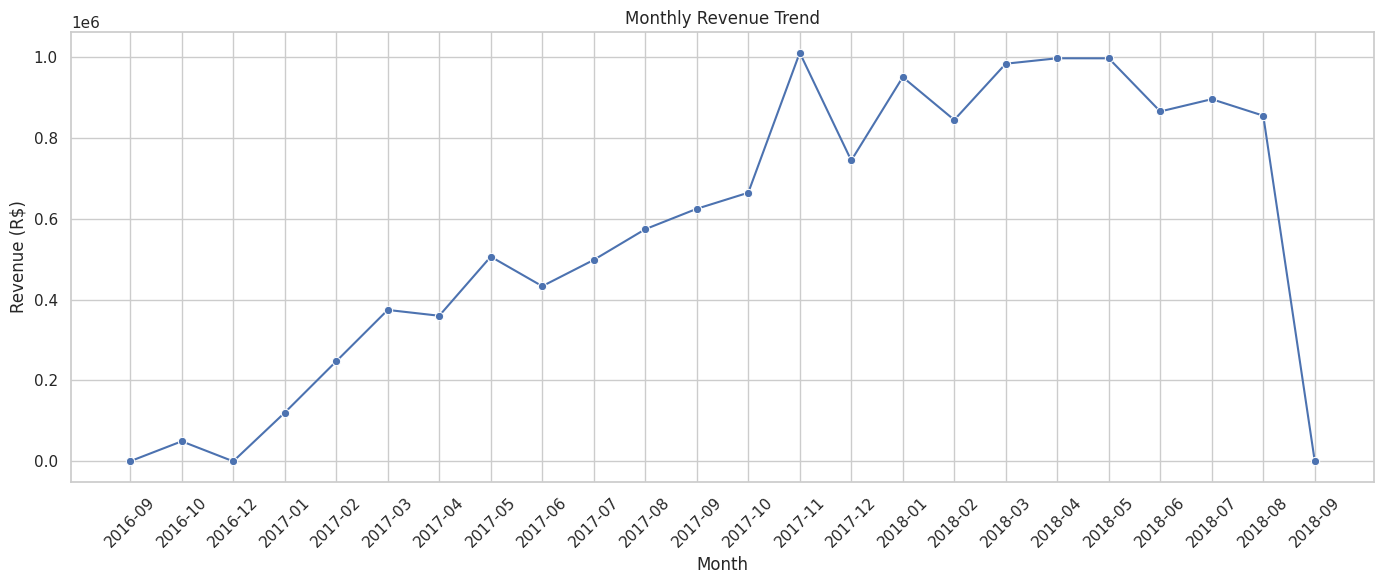

In [ ]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_sales,
    x="order_month",
    y="revenue",
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualisasi BQ1 — Top 10 Product Categories

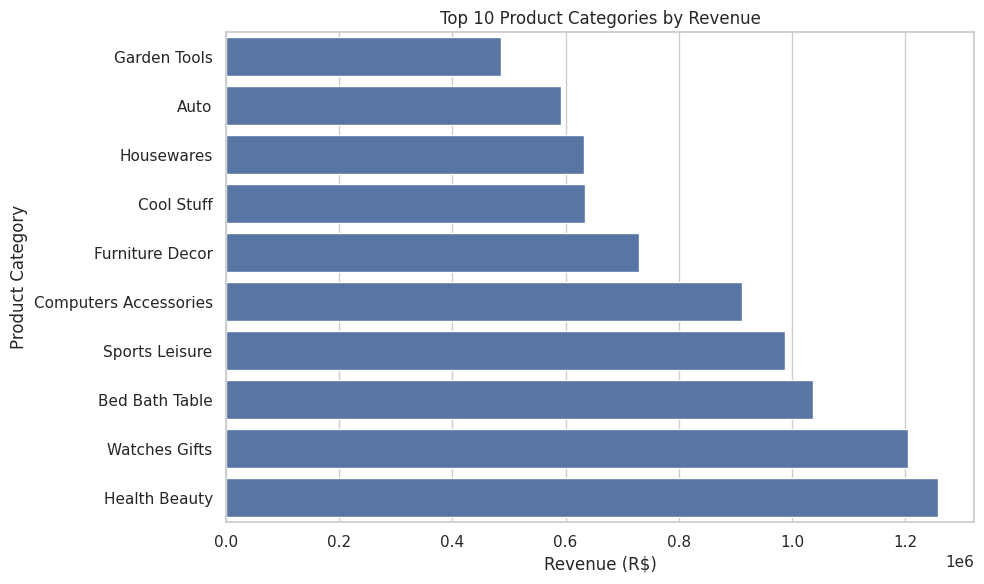

In [ ]:
top_categories = category_sales.head(10).sort_values("revenue")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_categories,
    x="revenue",
    y="product_category_name_english"
)
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## 6. Exploratory Data Analysis — Business Question 2

**Seberapa besar perbedaan rata-rata review score antara pesanan yang dikirim tepat waktu dan pesanan yang terlambat selama periode 2017 hingga 2018?**

In [ ]:
delivery_review = (
    df_review[
        df_review["delivery_status"].notna() &
        df_review["review_score"].notna() &
        df_review["order_year"].between(2017, 2018)
    ]
    .groupby("delivery_status", as_index=False)
    .agg(
        avg_review_score=("review_score", "mean"),
        total_orders=("order_id", "nunique")
    )
)

display(delivery_review)

,delivery_status,avg_review_score,total_orders
0,Late,2.55,7659
1,On Time,4.21,87902


In [ ]:
pivot_review = (
    delivery_review.set_index("delivery_status")["avg_review_score"]
)

on_time_score = pivot_review.get("On Time", np.nan)
late_score = pivot_review.get("Late", np.nan)
score_difference = on_time_score - late_score

print(f"Average review On Time: {on_time_score:.2f}")
print(f"Average review Late: {late_score:.2f}")
print(f"Difference: {score_difference:.2f} points")

Average review On Time: 4.21
Average review Late: 2.55
Difference: 1.66 points


### Visualisasi BQ2 — Average Review Score

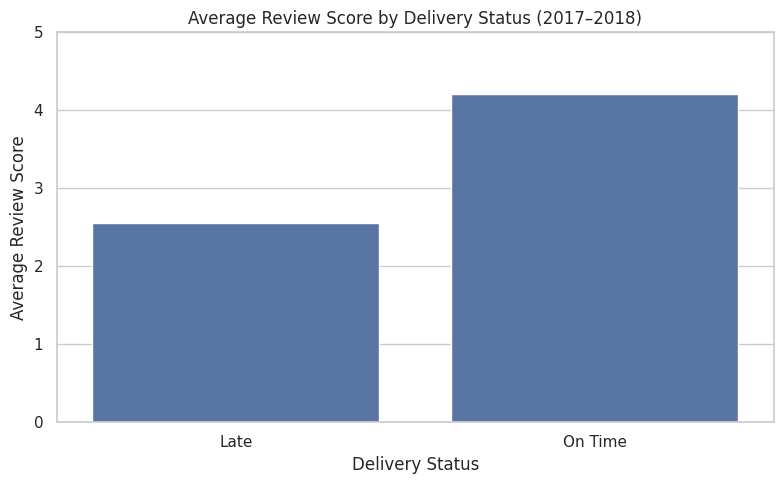

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=delivery_review,
    x="delivery_status",
    y="avg_review_score"
)
plt.title("Average Review Score by Delivery Status (2017–2018)")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

### Visualisasi BQ2 — Review Score Distribution

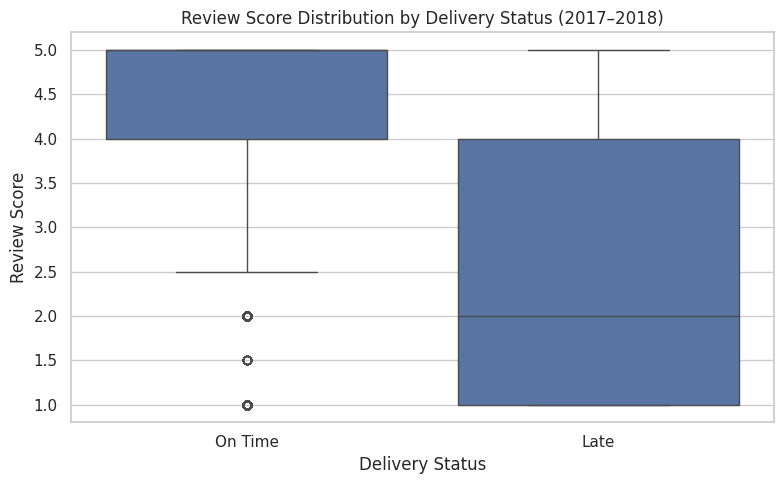

In [ ]:
plot_review = df_review[
    df_review["delivery_status"].notna() &
    df_review["review_score"].notna() &
    df_review["order_year"].between(2017, 2018)
].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_review,
    x="delivery_status",
    y="review_score"
)
plt.title("Review Score Distribution by Delivery Status (2017–2018)")
plt.xlabel("Delivery Status")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

## 7. Additional Analysis — Delivery Performance

Analisis tambahan ini digunakan untuk memperkuat recommendation dan dashboard.

In [ ]:
delivery_summary = (
    df_review[
        df_review["delivery_status"].notna() &
        df_review["order_year"].between(2017, 2018)
    ]
    .groupby("delivery_status", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        avg_delivery_difference_days=("delivery_difference_days", "mean")
    )
)

total_delivery_orders = delivery_summary["total_orders"].sum()
on_time_orders = delivery_summary.loc[
    delivery_summary["delivery_status"] == "On Time",
    "total_orders"
].sum()

on_time_rate = on_time_orders / total_delivery_orders * 100

display(delivery_summary)
print(f"On-time rate: {on_time_rate:.2f}%")

,delivery_status,total_orders,avg_delivery_difference_days
0,Late,7823,9.42
1,On Time,88381,-13.04


On-time rate: 91.87%


## 8. Conclusion

### Kesimpulan Business Question 1
Berdasarkan hasil analisis, revenue tertinggi terjadi pada November 2017 dengan total revenue sebesar 1,010,271.37. Sementara itu, kategori produk dengan kontribusi revenue terbesar adalah Health Beauty, dengan total revenue sebesar  1,258,681.34 atau sekitar 9.26% dari keseluruhan revenue. Hasil ini menunjukkan bahwa kategori Health Beauty memiliki kontribusi yang cukup penting terhadap performa penjualan dan dapat menjadi salah satu kategori yang perlu diprioritaskan dalam strategi penjualan.

### Kesimpulan Business Question 2
Berdasarkan analisis periode 2017–2018, terdapat perbedaan yang cukup besar pada rata-rata review score antara pesanan yang dikirim tepat waktu dan pesanan yang terlambat. Pesanan yang On Time memiliki rata-rata review score sebesar 4.21, sedangkan pesanan yang Late hanya memperoleh rata-rata 2.55. Dengan demikian, terdapat selisih sebesar 1.66 poin. Hasil ini menunjukkan bahwa keterlambatan pengiriman berkaitan dengan penurunan kepuasan pelanggan, sehingga ketepatan waktu pengiriman menjadi aspek penting yang perlu diperhatikan untuk meningkatkan customer experience.

In [ ]:
print("=== CONCLUSION NUMERICAL SUMMARY ===")
print(f"Peak revenue month      : {peak_month['order_month']}")
print(f"Peak monthly revenue    : R$ {peak_month['revenue']:,.2f}")
print(f"Top revenue category    : {top_category['product_category_name_english']}")
print(f"Top category revenue    : R$ {top_category['revenue']:,.2f}")
print(f"Top category share      : {top_category['revenue_share_pct']:.2f}%")
print(f"On-time review score    : {on_time_score:.2f}")
print(f"Late review score       : {late_score:.2f}")
print(f"Review score difference : {score_difference:.2f}")
print(f"On-time delivery rate   : {on_time_rate:.2f}%")

=== CONCLUSION NUMERICAL SUMMARY ===
Peak revenue month      : 2017-11
Peak monthly revenue    : R$ 1,010,271.37
Top revenue category    : Health Beauty
Top category revenue    : R$ 1,258,681.34
Top category share      : 9.26%
On-time review score    : 4.21
Late review score       : 2.55
Review score difference : 1.66
On-time delivery rate   : 91.87%


## 9. Recommendation / Action Items

1. **Sales:** Prioritaskan kategori dengan kontribusi revenue terbesar melalui pengelolaan stok, promosi, dan monitoring performa kategori secara berkala.
2. **Delivery:** Evaluasi seller, wilayah, atau proses logistik yang memiliki tingkat keterlambatan tinggi. Fokuskan perbaikan pada titik yang paling sering menyebabkan keterlambatan.
3. **Customer Experience:** Pantau review score bersama indikator delivery performance agar penurunan kepuasan pelanggan dapat dideteksi lebih awal.

## 10. Export Data untuk Streamlit

Notebook menghasilkan dataset agregat yang sudah siap digunakan dashboard.

In [ ]:
OUTPUT_DIR = Path("dashboard_data")
OUTPUT_DIR.mkdir(exist_ok=True)

monthly_sales.to_csv(OUTPUT_DIR / "monthly_sales.csv", index=False)
category_sales.to_csv(OUTPUT_DIR / "category_sales.csv", index=False)
delivery_review.to_csv(OUTPUT_DIR / "delivery_review.csv", index=False)
delivery_summary.to_csv(OUTPUT_DIR / "delivery_summary.csv", index=False)

dashboard_data = df_review[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_year",
        "order_month",
        "order_status",
        "product_category_name_english",
        "price",
        "freight_value",
        "revenue",
        "order_value",
        "delivery_difference_days",
        "delivery_status",
        "review_score"
    ]
].drop_duplicates()

dashboard_data.to_csv(
    OUTPUT_DIR / "dashboard_data.csv",
    index=False
)

print("Export selesai.")
print(list(OUTPUT_DIR.iterdir()))

Export selesai.
[PosixPath('dashboard_data/delivery_summary.csv'), PosixPath('dashboard_data/category_sales.csv'), PosixPath('dashboard_data/delivery_review.csv'), PosixPath('dashboard_data/dashboard_data.csv'), PosixPath('dashboard_data/monthly_sales.csv')]
